# Sections 4.4 and 5.1 — Selection of the Hamiltonian

Stage 1 (LASSO pre-filter), stage 2 (forward selection) and the stability tests of the selected raw terms. The long computations are run from the command line:

```
python 02_selection/prefilter_lasso.py --variants original grid-extended no-reweight   # ~5 min
python 02_selection/forward_selection.py                                          # several hours
python 02_selection/stability_tests.py                                            # ~1 h
python 02_selection/score_final_model.py                                          # needs the samples
```

This notebook shows the stored results.

In [1]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent            # the notebook lives in <root>/<chapter folder>/
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

def run(script, *args):
    """Run one script of this repository and print its output."""
    out = subprocess.run([sys.executable, script, *args], capture_output=True, text=True)
    print(out.stdout[-3000:] or out.stderr[-3000:])

def show(name, width=900):
    display(Image(filename=f'figures/{name}', width=width))

## Stage 1: LASSO-penalized pseudo-likelihood (retained candidates, all three variants)

In [2]:
lasso = pd.read_csv('results/selection/lasso_coefficients.csv')
lasso.pivot(index='candidate', columns='variant', values='coefficient').round(4)

variant,grid-extended,no-reweight,original
candidate,,,
S3,0.0000,0.0000,0.0000
S4,0.0000,0.0000,0.0000
sG,0.0000,0.0000,0.0000
sig2,-4.7394,-6.6052,-7.0653
sig2H,3.8554,5.3800,5.7505
sig2L,3.0131,4.2275,4.5122
t1,0.0406,0.0406,0.0337
t1_HH,0.0141,0.0229,0.0198
t1_LL,0.0000,0.0000,0.0000


## Stage 2: forward selection on the German grid (thesis run)

In [3]:
pd.read_csv('results/selection/forward_selection_trace_thesis.csv').drop(columns='note').round(4)

,step,candidate,raw_score,pen_score,added
0,0,"(base: mLL, mLH, mHH)",0.2841,0.2841,True
1,1,sig2,0.2385,0.2435,True
2,1,sig2H,0.2539,0.2589,False
3,1,sig2L,0.2693,0.2743,False
4,1,t1,0.2582,0.2632,False
5,1,t1_HH,0.2524,0.2574,False
6,2,sig2H,0.2370,0.2470,False
7,2,sig2L,0.2565,0.2665,False
8,2,t1,0.1758,0.1858,True
9,2,t1_HH,0.1963,0.2063,False


## Stability of sigma² and AKS in reduced models (Serbia, Czech Republic)
Mean simulated degree variance and AKS by parameter value; sigma² jumps between 3.5 and 5.0, AKS changes gradually.

In [4]:
sw = pd.read_csv('results/selection/reduced_model_sweeps.csv')
sig = sw[sw.term == 'sig2'].groupby(['country', 'beta']).sig2.mean().unstack(0).round(1)
aks = sw[sw.term == 'akstar'].groupby(['country', 'beta']).akstar.mean().unstack(0).round(1)
display(sig); display(aks)

country,CZ,RS
beta,,
-4.0,1.7,1.6
-2.5,1.8,1.7
-1.0,2.1,2.2
0.5,2.5,2.1
2.0,3.5,2.8
3.5,3.6,3.6
5.0,113.1,115.3
6.5,210.1,119.2
8.0,212.4,151.3


country,CZ,RS
beta,,
-30.0,1.7,1.3
-27.0,1.5,1.3
-24.0,1.8,1.4
-21.0,2.2,1.6
-18.0,2.2,1.9
-15.0,2.6,2.4
-12.0,3.3,2.1
-9.0,4.0,3.3
-6.0,5.2,3.7


## Figure 8 — triangle count vs. beta_t1 with and without t2

written



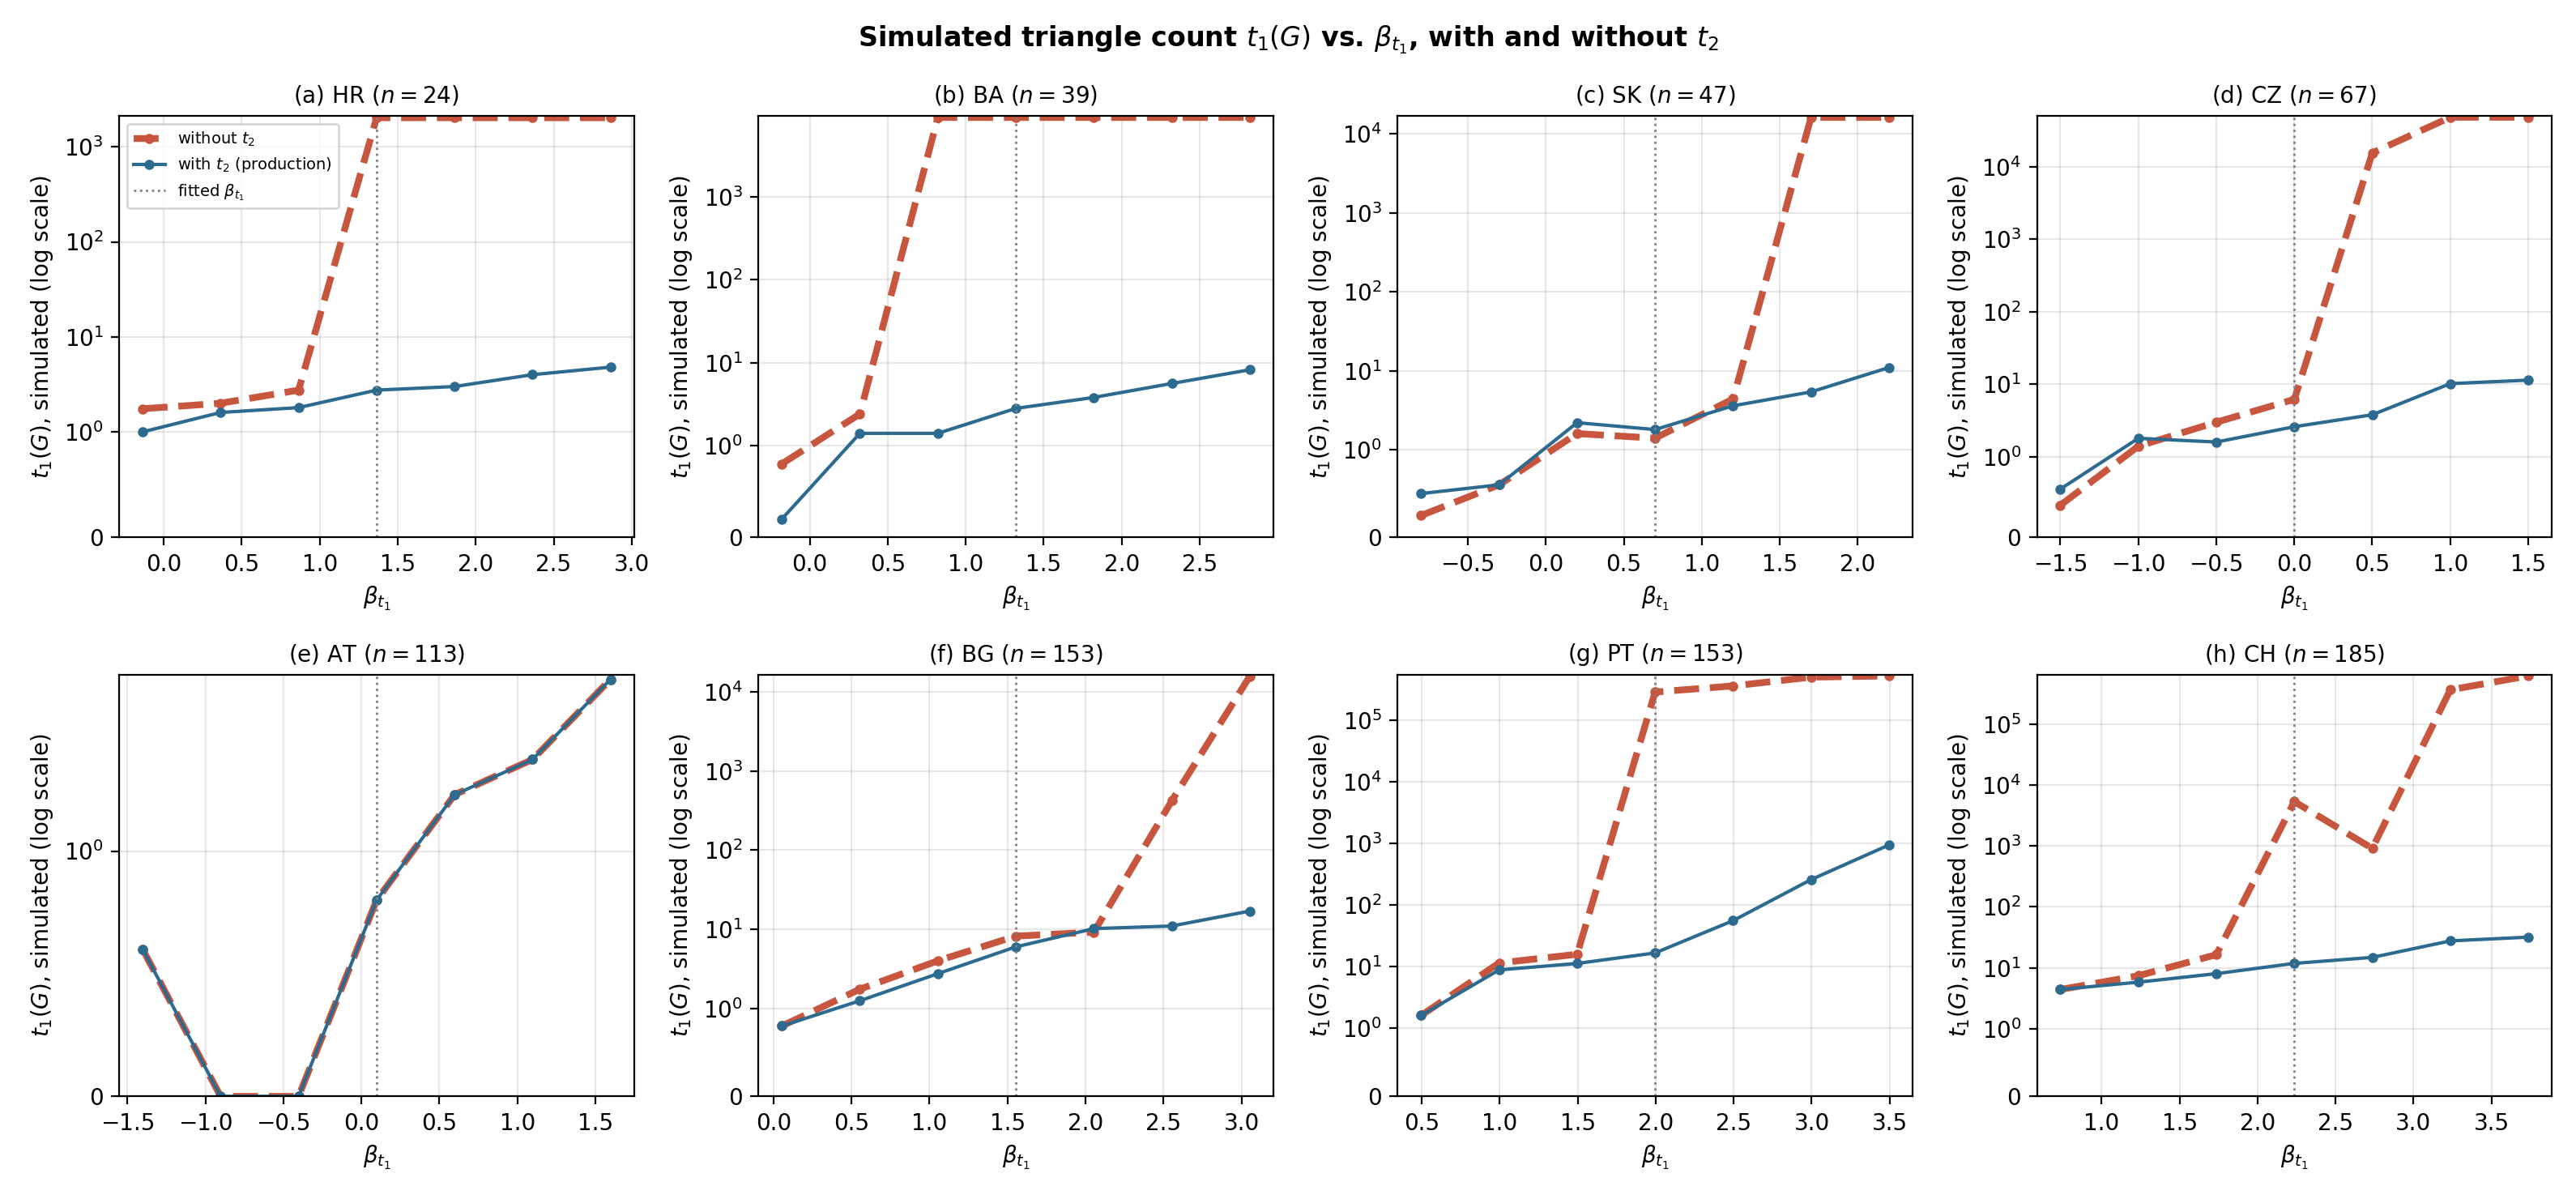

In [5]:
run('02_selection/fig_t1_sweep.py'); show('model_t1_cliff_sweep_symlog.png')